## Observation Notes
#### Class imbalance 
1. GALAXY    0.653818
2. QSO       0.202899
3. STAR      0.143283

#### 'u', 'g', 'r', 'i', 'z'
- These are the different filters capturing light signals from interstellar space objects, we are getting magnitude of for each filter
- Lower magnitude brighter the ligh and vice versa 

#### Redshift
rshft = (wl_observed - wl_emitted) / wl_emitted

#### spectral_type
| Value | Meaning                      | Temperature |
| ----- | ---------------------------- | ----------- |
| O/B   | Very hot blue stars          | Highest     |
| A/F   | Hot-white stars              | High        |
| G/K   | Sun-like yellow/orange stars | Medium      |
| M     | Red stars                    | Coolest     |


In [12]:
# Imports
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
import lightgbm as lgb
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')


# Configurations
ROOT_PATH = "playground-series-s6e6"
EXTERNEL_DATA_PATH = "playground-series-s6e6/externel_dataset/star_classification_pred_spectral_type_galaxy_pop_org.csv"
BENCHMARK = 0.9651 # <- LightGBM
ID = 'id'
TARGET = 'class'
TARGET_MAPPING = {
    "GALAXY": 0,
    "QSO": 1,
    "STAR": 2
}
TARGET_INV_MAPPING = {
    0:"GALAXY",
    1:"QSO",
    2:"STAR"
}
N_FOLDS = 5
SEED = 42
XGB_OPTUNA = False
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cpu


In [3]:
train_df_org_1 = pd.read_csv(os.path.join(ROOT_PATH, 'train.csv'))
test_df_org = pd.read_csv(os.path.join(ROOT_PATH, 'test.csv'))
sub_org = pd.read_csv(os.path.join(ROOT_PATH, 'sample_submission.csv'))
extra_df_org = pd.read_csv(os.path.join(EXTERNEL_DATA_PATH)) # Extra data

# train_df_org = pd.concat([train_df_org_1, extra_df_org], axis='rows', ignore_index=True)
extra_df_aligned = extra_df_org[train_df_org_1.columns]
train_df_org = pd.concat([train_df_org_1, extra_df_aligned], axis='rows', ignore_index=True)

print(f"Shap of train : {train_df_org.shape} | test : {test_df_org.shape} | submissions : {sub_org.shape} | extra : {extra_df_org.shape}")
print(f"Target distribution train : \n{train_df_org['class'].value_counts(normalize=True)} | extra : \n{extra_df_org['class'].value_counts(normalize=True)}")

Shap of train : (677347, 12) | test : (247435, 11) | submissions : (247435, 2) | extra : (100000, 12)
Target distribution train : 
class
GALAXY    0.645053
QSO       0.200937
STAR      0.154010
Name: proportion, dtype: float64 | extra : 
class
GALAXY    0.59445
STAR      0.21594
QSO       0.18961
Name: proportion, dtype: float64


## Correlation (Train | Test)
- Show correlation plot
- Decide Feature Engineering

Numerical columns : ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
Categorical columns : ['spectral_type', 'galaxy_population']


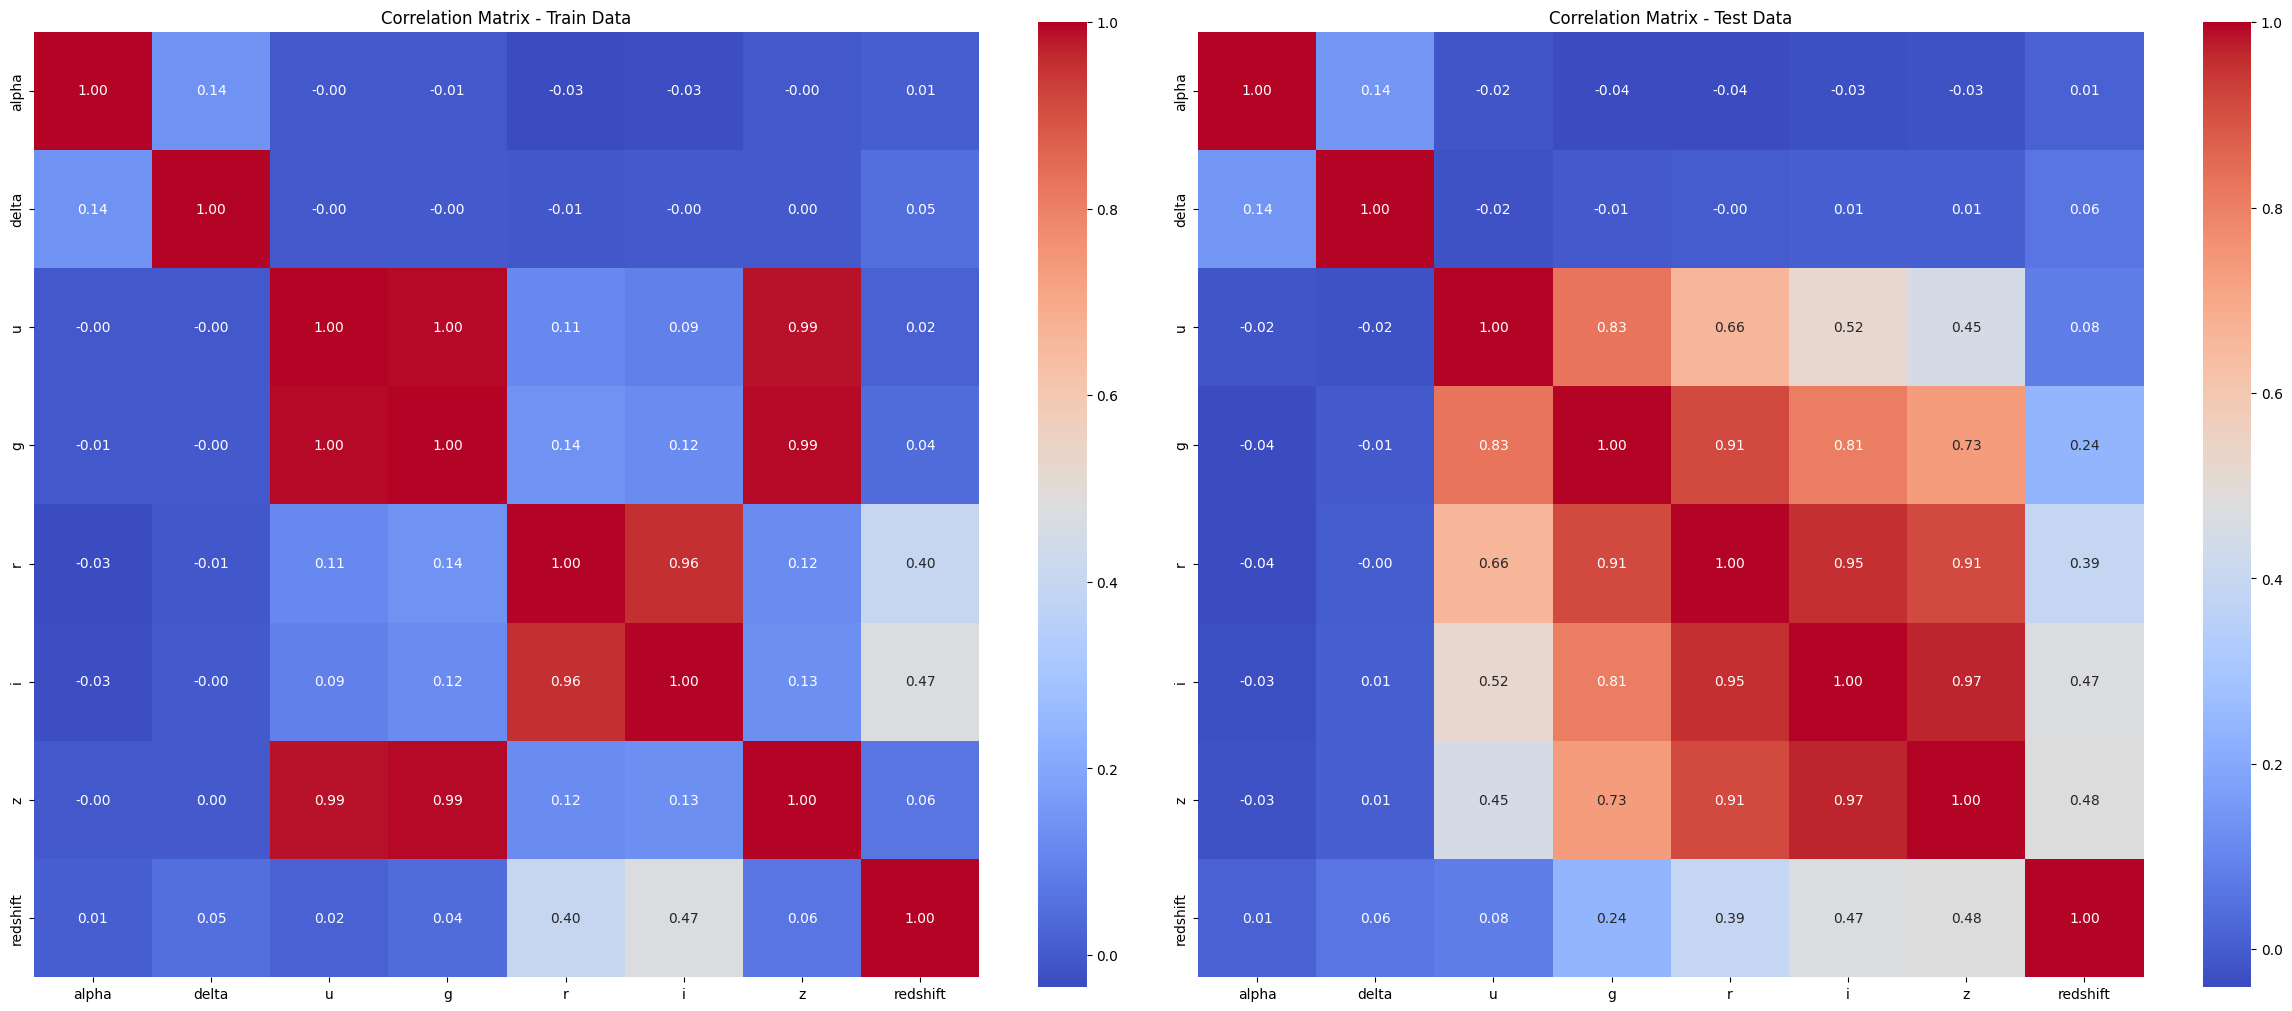

In [4]:
train_df = train_df_org.copy()
test_df = test_df_org.copy()

n_cols = train_df.drop(columns=[ID, TARGET], axis='columns').select_dtypes(exclude='object').columns.to_list()
c_cols = train_df.drop(columns=[ID, TARGET], axis='columns').select_dtypes(include='object').columns.to_list()
print(f"Numerical columns : {n_cols}")
print(f"Categorical columns : {c_cols}")

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(train_df[n_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=axes[0])
axes[0].set_title("Correlation Matrix - Train Data")

sns.heatmap(test_df[n_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=axes[1])
axes[1].set_title("Correlation Matrix - Test Data")

plt.tight_layout()
plt.show()

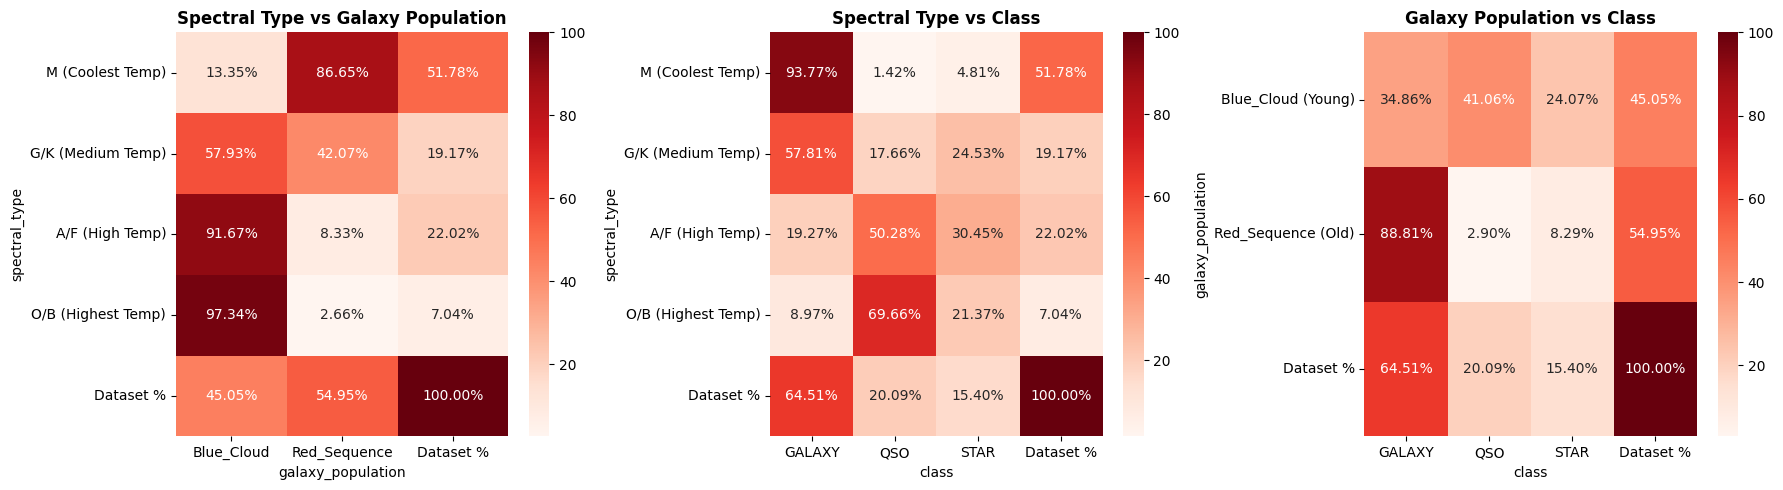

In [5]:
def add_dataset_pct(ct, row_col, col_col):
    ct['Dataset %'] = row_col.value_counts(normalize=True).mul(100).reindex(ct.index)
    ct.loc['Dataset %'] = pd.concat([col_col.value_counts(normalize=True).mul(100).reindex(ct.columns[:-1]), pd.Series({'Dataset %': 100})])
    return ct

ct1 = add_dataset_pct(pd.crosstab(train_df['spectral_type'], train_df['galaxy_population'], normalize='index').mul(100), train_df['spectral_type'], train_df['galaxy_population'])
ct2 = add_dataset_pct(pd.crosstab(train_df['spectral_type'], train_df['class'], normalize='index').mul(100), train_df['spectral_type'], train_df['class'])
ct3 = add_dataset_pct(pd.crosstab(train_df['galaxy_population'], train_df['class'], normalize='index').mul(100), train_df['galaxy_population'], train_df['class'])


spectral_labels = [
    'M (Coolest Temp)',
    'G/K (Medium Temp)',
    'A/F (High Temp)',
    'O/B (Highest Temp)',
    'Dataset %'
]

galaxy_labels = [
    'Blue_Cloud (Young)',
    'Red_Sequence (Old)',
    'Dataset %'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

temp_order = ['M', 'G/K', 'A/F', 'O/B']
ct1 = ct1.reindex(temp_order + ['Dataset %'])
ct2 = ct2.reindex(temp_order + ['Dataset %'])

galaxy_order = ['Blue_Cloud', 'Red_Sequence']
ct3 = ct3.reindex(galaxy_order + ['Dataset %'])

sns.heatmap(ct1, annot=True, fmt='.2f', cmap='Reds', ax=axes[0])
sns.heatmap(ct2, annot=True, fmt='.2f', cmap='Reds', ax=axes[1])
sns.heatmap(ct3, annot=True, fmt='.2f', cmap='Reds', ax=axes[2])

# Titles
axes[0].set_title('Spectral Type vs Galaxy Population', fontweight='bold')
axes[1].set_title('Spectral Type vs Class', fontweight='bold')
axes[2].set_title('Galaxy Population vs Class', fontweight='bold')

# Replace row labels
axes[0].set_yticklabels(spectral_labels, rotation=0)
axes[1].set_yticklabels(spectral_labels, rotation=0)
axes[2].set_yticklabels(galaxy_labels, rotation=0)

for ax in axes:
    for text in ax.texts:
        text.set_text(text.get_text() + '%')

plt.tight_layout()
plt.show()

## Feature Engineering

In [6]:
def engineer_astro_features(df, c_cols=c_cols, te=True, encoder=None):
    df = df.copy()
    c_cols = c_cols.copy()

    df['spectral_rank_fe'] = df['spectral_type'].map({'M':1, 'G/K':2, 'A/F':3, 'O/B':4})
    df['population_rank_fe'] = df['galaxy_population'].map({'Red_Sequence':0,'Blue_Cloud':1})
    df['astro_score_fe'] = df['spectral_rank_fe'] * (df['population_rank_fe'] + 1)
    df['is_red_galaxy_candidate_fe'] = ((df['spectral_type']=='M') & (df['galaxy_population']=='Red_Sequence')).astype('int8')
    df['is_qso_candidate_fe'] = ((df['spectral_type'].isin(['A/F','O/B'])) & (df['galaxy_population']=='Blue_Cloud')).astype('int8')
    df['_&_'.join([col + "_fe" for col in c_cols])] = df[c_cols].apply(lambda x: '_&_'.join(x.astype(str)), axis=1)
    c_cols.append('_&_'.join([col + "_fe" for col in c_cols]))
    

    fltr_cols = ['u', 'g', 'r', 'i', 'z']
    df['dom_fltr_fe'] = df[fltr_cols].idxmin(axis=1)
    c_cols.append('dom_fltr_fe')
    agg_map = { 'mean': 'mean','max': 'max','min': 'min','std': 'std','med': 'median'}
    for suffix, func in agg_map.items():
        df[f'{suffix}_fltr_fe'] = getattr(df[fltr_cols], func)(axis=1)

    for i in range(len(fltr_cols)):
        for j in range(i + 1, len(fltr_cols)):
            b1, b2 = fltr_cols[i], fltr_cols[j]
            df[f'{b1}_{b2}'] = df[b1] - df[b2]
    
    # Redshift interaction terms (multiplication) across all 10 color index bands
    df['u_g_redshift'] = df['u_g'] * df['redshift']
    df['g_r_redshift'] = df['g_r'] * df['redshift']
    df['r_i_redshift'] = df['r_i'] * df['redshift']
    df['i_z_redshift'] = df['i_z'] * df['redshift']
    df['u_r_redshift'] = df['u_r'] * df['redshift']
    df['g_i_redshift'] = df['g_i'] * df['redshift']
    df['r_z_redshift'] = df['r_z'] * df['redshift']
    df['u_i_redshift'] = df['u_i'] * df['redshift']
    df['g_z_redshift'] = df['g_z'] * df['redshift']
    df['u_z_redshift'] = df['u_z'] * df['redshift']

    # Color curvature differences (differences of differences)
    df['ug_gr'] = df['u_g'] - df['g_r']
    df['ug_ri'] = df['u_g'] - df['r_i']
    df['ug_iz'] = df['u_g'] - df['i_z']
    df['gr_ri'] = df['g_r'] - df['r_i']
    df['gr_iz'] = df['g_r'] - df['i_z']
    df['ri_iz'] = df['r_i'] - df['i_z']
    
    # Discretized stellar color temperature bins
    df['stellar_color_bin_fe'] = pd.cut(
        df['g_r'],
        bins=[-np.inf, 0.0, 0.4, 0.8, 1.2, np.inf],
        labels=[0, 1, 2, 3, 4]
    ).fillna(2).astype(int)

    # Equatorial coordinates -> Cartesian coordinates
    alpha_rad = np.radians(df['alpha'])
    delta_rad = np.radians(df['delta'])

    df['coord_x_fe'] = np.cos(delta_rad) * np.cos(alpha_rad)
    df['coord_y_fe'] = np.cos(delta_rad) * np.sin(alpha_rad)
    df['coord_z_fe'] = np.sin(delta_rad)

    # Redshift-scaled coordinates
    df['coord_x_redshift_fe'] = df['coord_x_fe'] * df['redshift']
    df['coord_y_redshift_fe'] = df['coord_y_fe'] * df['redshift']
    df['coord_z_redshift_fe'] = df['coord_z_fe'] * df['redshift']

    # Galactic coordinate transformation (J2000 NGP)
    x_gal = -0.05487554 * df['coord_x_fe'] - 0.87343710 * df['coord_y_fe'] - 0.48383499 * df['coord_z_fe']
    y_gal =  0.49410945 * df['coord_x_fe'] - 0.44482959 * df['coord_y_fe'] + 0.74698225 * df['coord_z_fe']
    z_gal = -0.86766614 * df['coord_x_fe'] - 0.19807639 * df['coord_y_fe'] + 0.45598380 * df['coord_z_fe']

    df['gal_x_fe'] = x_gal
    df['gal_y_fe'] = y_gal
    df['gal_z_fe'] = z_gal

    stats_df = df[fltr_cols]
    dom_vals = stats_df.to_numpy()[np.arange(len(df)), stats_df.columns.get_indexer(df['dom_fltr_fe'])]
    df['dom_redshift_magn_fe'] = dom_vals * df['redshift'].to_numpy()

    # Ordinal Encoding 
    if te == True:
        encoder = OrdinalEncoder()
        encoder.fit(df[c_cols])
        df[c_cols] = encoder.transform(df[c_cols])
        df[TARGET] = df[TARGET].map(TARGET_MAPPING)
        return df, encoder, list(set(c_cols))
    else:
        df[c_cols] = encoder.transform(df[c_cols])
        return df, list(set(c_cols))
    

print(f"Shape before feature engineering: {train_df.shape} | {test_df.shape}")
# train_df1 = train_df.iloc[:len(train_df)//2]
# train_df2 = train_df.iloc[len(train_df)//2:]

train_df_fe, encoder, c_cols_fe = engineer_astro_features(train_df, te=True)
test_df_fe, c_cols_fe = engineer_astro_features(test_df, te=False, encoder=encoder)

print(f"Shape after feature engineering: {train_df_fe.shape} | {test_df_fe.shape}")

Shape before feature engineering: (677347, 12) | (247435, 11)
Shape after feature engineering: (677347, 61) | (247435, 60)


## Target Encoding 

Applying target encoding on training data with K-Fold strategy ...
(541877, 61) (135470, 61)
(541877, 61) (135470, 61)
(541877, 61) (135470, 61)
(541877, 61) (135470, 61)
(541877, 73) (135470, 73)
(541877, 73) (135470, 73)
(541877, 73) (135470, 73)
(541877, 73) (135470, 73)
(541878, 73) (135469, 73)
(541878, 73) (135469, 73)
(541878, 73) (135469, 73)
(541878, 73) (135469, 73)
(541878, 73) (135469, 73)
(541878, 73) (135469, 73)
(541878, 73) (135469, 73)
(541878, 73) (135469, 73)
(541878, 73) (135469, 73)
(541878, 73) (135469, 73)
(541878, 73) (135469, 73)
(541878, 73) (135469, 73)
Applying same stats of train data to test data ...
Shape of (Train - Encoded): (677347, 73) | (Test - Encoded): (247435, 72)


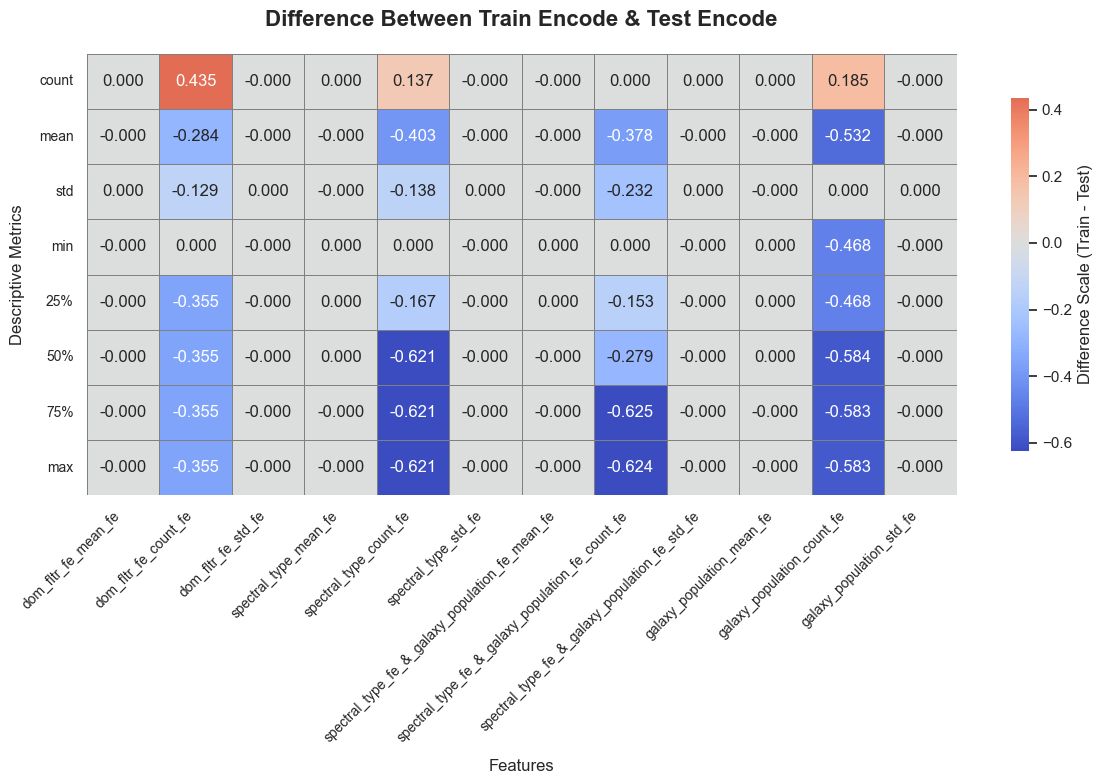

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

train_df_te = train_df_fe.copy()
test_df_te = test_df_fe.copy()

encoded_data = {

}
print("Applying target encoding on training data with K-Fold strategy ...")
for train_idx, val_idx in skf.split(train_df_fe.drop([TARGET], axis='columns'), train_df_fe[TARGET]):
    X_tr = train_df_te.iloc[train_idx]
    X_val = train_df_te.iloc[val_idx]

    for col in c_cols_fe:
        print(X_tr.shape, X_val.shape)  
        stats = X_tr.groupby(col)[TARGET].agg(['mean', 'count', 'std'])
        idx = X_val.index
        X_val = X_val.merge(stats, on=col, how='left')
        X_val.index = idx
    
        train_df_te.loc[val_idx, f'{col}_mean_fe'] = X_val['mean']
        train_df_te.loc[val_idx, f'{col}_count_fe'] = X_val['count']
        train_df_te.loc[val_idx, f'{col}_std_fe'] = X_val['std']  

        encoded_data[col] = X_val[[col, 'mean', 'count', 'std']].copy()

        X_val.drop(['mean', 'std', 'count'], axis='columns', inplace=True)


print("Applying same stats of train data to test data ...")

for col in c_cols_fe:
    encoded_stats = encoded_data[col].drop_duplicates(subset=[col]).set_index(col)

    test_df_te[f'{col}_mean_fe'] = test_df_te[col].map(encoded_stats['mean'])
    test_df_te[f'{col}_count_fe'] = test_df_te[col].map(encoded_stats['count'])
    test_df_te[f'{col}_std_fe'] = test_df_te[col].map(encoded_stats['std'])


print(f"Shape of (Train - Encoded): {train_df_te.shape} | (Test - Encoded): {test_df_te.shape}")

train_te_des = train_df_te[[col for col in train_df_te.columns if col.endswith('_mean_fe') or col.endswith('_count_fe') or col.endswith('_std_fe')]].describe()
test_te_des = test_df_te[[col for col in train_df_te.columns if col.endswith('_mean_fe') or col.endswith('_count_fe') or col.endswith('_std_fe')]].describe()

scaler = MinMaxScaler()

train_te_des_norm = pd.DataFrame(scaler.fit_transform(train_te_des), columns=train_te_des.columns, index=train_te_des.index)
test_te_des_norm = pd.DataFrame(scaler.fit_transform(test_te_des), columns=test_te_des.columns, index=test_te_des.index)
des_diff = train_te_des_norm - test_te_des_norm

plt.figure(figsize=(12, 8), dpi=100)
sns.set_theme(style="white")

ax = sns.heatmap(
    des_diff,
    cmap="coolwarm",      
    center=0,             
    annot=True,           
    fmt=".3f",            
    linewidths=0.5,       
    linecolor='gray',     
    cbar_kws={
        'label': 'Difference Scale (Train - Test)', 
        'shrink': 0.8
    }                     
)

plt.title("Difference Between Train Encode & Test Encode", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Features", fontsize=12, labelpad=10)
plt.ylabel("Descriptive Metrics", fontsize=12, labelpad=10)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
X, y = train_df_te.drop([ID, TARGET], axis='columns'), train_df_te[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# best_lgb_params = {'n_estimators': 1597, 'learning_rate': 0.013138718074099392, 'num_leaves': 125, 'max_depth': 14, 'min_child_samples': 11, 'subsample': 0.9216434598794973, 'colsample_bytree': 0.6907961540496335, 'reg_alpha': 1.7363032673677048, 'reg_lambda': 0.1520511809225233, 'min_split_gain': 0.5493683201475772}
best_lgb_params = {'n_estimators': 1765, 'learning_rate': 0.010488755966065043, 'num_leaves': 124, 'max_depth': 13, 'min_child_samples': 6, 'subsample': 0.8565711988177247, 'colsample_bytree': 0.8170007643681162, 'reg_alpha': 0.5114444055800705, 'reg_lambda': 0.007243721824937548, 'min_split_gain': 0.7325616646035212}
best_lgb_params['class_weight']='balanced'
best_lgb_params['random_state']=42

# 5-Fold Cross-Validation with Balanced Accuracy Score
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_scores = []

print(f"{'Fold':<6} {'Balanced Accuracy':^20}")
print("-" * 30)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Train XGBoost model
    model = lgb.LGBMClassifier(
    **best_lgb_params,
    verbose=-1
    )
    
    model.fit(X_tr, y_tr)
    
    # Predict and calculate balanced accuracy
    y_pred = model.predict(X_val)
    balanced_acc = balanced_accuracy_score(y_val, y_pred)
    fold_scores.append(balanced_acc)
    
    print(f"{fold:<6} {balanced_acc:>20.4f}")

print("-" * 30)
print(f"{'Mean':<6} {np.mean(fold_scores):>20.4f}")
print(f"{'Std':<6} {np.std(fold_scores):>20.4f}")

Fold    Balanced Accuracy  
------------------------------
1                    0.9638
2                    0.9649
3                    0.9647


KeyboardInterrupt: 

In [9]:
# LightGBM Benchmark
# Fold    Balanced Accuracy  
# ------------------------------
# 1                    0.9652
# 2                    0.9656
# 3                    0.9647
# 4                    0.9654
# 5                    0.9644
# ------------------------------
# Mean                 0.9651
# Std                  0.0004

## Final Model Training

In [19]:
best_lgb_params = {'n_estimators': 1765, 'learning_rate': 0.010488755966065043, 'num_leaves': 124, 'max_depth': 13, 'min_child_samples': 6, 'subsample': 0.8565711988177247, 'colsample_bytree': 0.8170007643681162, 'reg_alpha': 0.5114444055800705, 'reg_lambda': 0.007243721824937548, 'min_split_gain': 0.7325616646035212}
best_lgb_params['class_weight']='balanced'
best_lgb_params['random_state']=42

lgb_model = lgb.LGBMClassifier(
    **best_lgb_params, 
    verbose=-1
    )
lgb_model.fit(X, y)

FILE_NAME = "lgb_10_06_2026_v2"
SUB_FILE_NAME = f"submissions\\{FILE_NAME}.csv"
PROB_FILE_NAME = f"probabilities\\{FILE_NAME}.csv"

probabilities = lgb_model.predict_proba(test_df_te.drop([ID], axis='columns'))
class_names = ['GALAXY', 'QSO', 'STAR'] 
proba_df_classes = pd.DataFrame(probabilities, columns=class_names)
proba_df = pd.concat([test_df_te[ID].reset_index(drop=True), proba_df_classes], axis=1)
proba_df.to_csv(PROB_FILE_NAME, index=False)

predictions = pd.Series(lgb_model.predict(test_df_te.drop([ID], axis='columns'))).map(TARGET_INV_MAPPING)
sub_df = pd.DataFrame({ID:test_df_te[ID], TARGET:predictions})
sub_df.to_csv(SUB_FILE_NAME, index=False)
sub_df.head()

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
